In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# install Hangul font

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Ign:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1
Ign:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2min 58s (58.1 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf

In [2]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

# [중요] 코랩 환경에서 출력을 보장하는 설정
pio.renderers.default = 'colab'

# 데이터 불러오기
file_name = '/content/A0067885_최신데이터.xlsx'
df = pd.read_excel(file_name)

# 데이터 전처리
df_firm = df[df['Firm/Forecast'].astype(str).str.strip().str.capitalize() == 'Firm'].copy()

# 날짜 정렬 로직 (datetime 객체 활용)
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_firm['Month_Num'] = df_firm['Month'].str.strip().map(month_map)

# 연-월-일 순서로 정렬된 임시 컬럼 생성
df_firm['Sorting_Date'] = pd.to_datetime(df_firm[['Year', 'Month_Num', 'Day']].rename(columns={'Month_Num': 'month', 'Year': 'year', 'Day': 'day'}))
df_firm = df_firm.sort_values(by='Sorting_Date')

# 이상치 판별
Q1 = df_firm['Quantity'].quantile(0.25)
Q3 = df_firm['Quantity'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 범례(Legend)에 표시될 그룹 설정
df_firm['Display_Group'] = df_firm.apply(
    lambda x: 'Outlier (이상치)' if (x['Quantity'] < lower_bound or x['Quantity'] > upper_bound)
    else x['Month'], axis=1
)

# 색상 지정 (이상치는 검은색)
color_map = {'Outlier (이상치)': '#000000'}

# 시각화 (X축 정렬을 위해 category_orders 매개변수 사용)
fig = px.scatter(
    df_firm,
    x='ID_Release',
    y='Quantity',
    color='Display_Group',
    color_discrete_map=color_map,
    category_orders={'ID_Release': df_firm['ID_Release'].unique().tolist()}, # 정렬된 리스트 주입
    hover_data={'ID_Release': True, 'Year': True, 'Month': True, 'Day': True, 'Quantity': ':.2f'},
    title='A0067885 ID_Release별 Firm Quantity Trend',
    labels={'Quantity': '수량 (pc)', 'ID_Release': '릴리즈 번호', 'Display_Group': '구분'},
    template='plotly_white'
)

# 그래프 디테일 설정
fig.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')), opacity=0.8)
fig.update_layout(
    height=600,
    xaxis=dict(tickangle=-45, type='category'), # X축 설정 단순화
    margin=dict(l=50, r=50, b=150, t=80),
    legend_title_text='월별 및 이상치',
    hoverlabel=dict(bgcolor="white", font_size=13)
)

# 코랩에서 확인용
fig.show()

# ---------------------------------------------------------
# [중요] nbviewer용 다운로드 직전 필수 단계:
# 아래 코드를 주석 해제하고 한 번 더 실행한 뒤 다운로드하세요!
pio.renderers.default = "notebook_connected"
fig.show()
# ---------------------------------------------------------

In [ ]:
import pandas as pd
import plotly.express as px

# 데이터 불러오기
file_name = '/content/A0028219_최신데이터.xlsx'
df = pd.read_excel(file_name)

# 데이터 전처리
df_firm = df[df['Firm/Forecast'].astype(str).str.strip().str.capitalize() == 'Firm'].copy()

# 월 이름을 숫자로 변환
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_firm['Month_Num'] = df_firm['Month'].str.strip().map(month_map)

# 실제 날짜(Sorting_Date) 컬럼 생성 및 정렬
# Year, Month_Num, Day를 합쳐 진짜 '날짜' 데이터를 만듦.
df_firm['Sorting_Date'] = pd.to_datetime(pd.DataFrame({
    'year': df_firm['Year'],
    'month': df_firm['Month_Num'],
    'day': df_firm['Day']
}))

# 만든 날짜를 기준으로 데이터를 정렬.
df_firm = df_firm.sort_values(by='Sorting_Date')

# 이상치(Outlier) 판별 및 그룹화
Q1 = df_firm['Quantity'].quantile(0.25)
Q3 = df_firm['Quantity'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_firm['Display_Group'] = df_firm.apply(
    lambda x: 'Outlier (이상치)' if (x['Quantity'] < lower_bound or x['Quantity'] > upper_bound)
    else x['Month'], axis=1
)

# 시각화 설정
# 이상치는 검은색, 나머지는 자동 색상
color_map = {'Outlier (이상치)': '#000000'}

# 정렬된 데이터프레임에서 ID_Release의 순서를 리스트로 추출.
ordered_id_list = df_firm['ID_Release'].unique().tolist()

fig = px.scatter(
    df_firm,
    x='ID_Release',
    y='Quantity',
    color='Display_Group',
    color_discrete_map=color_map,
    hover_data={
        'ID_Release': True,
        'Year': True,
        'Month': True,
        'Day': True,
        'Quantity': ':.3f'
    },
    title='A0028219 ID_Release별 Firm Quantity Trend',
    labels={'Quantity': '수량 (pc)', 'ID_Release': '릴리즈 번호', 'Display_Group': '구분'},
    template='plotly_white'
)

# X축 정렬 강제 고정
fig.update_xaxes(
    type='category',
    categoryorder='array',
    categoryarray=ordered_id_list, # 위에서 만든 날짜순 리스트를 주입
    tickangle=-45
)

fig.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')), opacity=0.8)

fig.update_layout(
    height=700,
    margin=dict(l=50, r=50, b=150, t=80),
    legend_title_text='월별 및 이상치',
    hoverlabel=dict(bgcolor="white", font_size=13)
)

fig.show()

In [ ]:
import pandas as pd
import plotly.express as px

# 데이터 불러오기
file_name = '/content/A0030814X_최신데이터.xlsx'
df = pd.read_excel(file_name)

# 데이터 전처리
df_firm = df[df['Firm/Forecast'].astype(str).str.strip().str.capitalize() == 'Firm'].copy()

# 월 이름을 숫자로 변환
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_firm['Month_Num'] = df_firm['Month'].str.strip().map(month_map)

# 실제 날짜(Sorting_Date) 컬럼 생성 및 정렬
# Year, Month_Num, Day를 합쳐 진짜 '날짜' 데이터를 만듦.
df_firm['Sorting_Date'] = pd.to_datetime(pd.DataFrame({
    'year': df_firm['Year'],
    'month': df_firm['Month_Num'],
    'day': df_firm['Day']
}))

# 만든 날짜를 기준으로 데이터를 정렬.
df_firm = df_firm.sort_values(by='Sorting_Date')

# 이상치(Outlier) 판별 및 그룹화
Q1 = df_firm['Quantity'].quantile(0.25)
Q3 = df_firm['Quantity'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_firm['Display_Group'] = df_firm.apply(
    lambda x: 'Outlier (이상치)' if (x['Quantity'] < lower_bound or x['Quantity'] > upper_bound)
    else x['Month'], axis=1
)

# 시각화 설정
# 이상치는 검은색, 나머지는 자동 색상
color_map = {'Outlier (이상치)': '#000000'}

# 정렬된 데이터프레임에서 ID_Release의 순서를 리스트로 추출.
ordered_id_list = df_firm['ID_Release'].unique().tolist()

fig = px.scatter(
    df_firm,
    x='ID_Release',
    y='Quantity',
    color='Display_Group',
    color_discrete_map=color_map,
    hover_data={
        'ID_Release': True,
        'Year': True,
        'Month': True,
        'Day': True,
        'Quantity': ':.3f'
    },
    title='A0030814X ID_Release별 Firm Quantity Trend',
    labels={'Quantity': '수량 (pc)', 'ID_Release': '릴리즈 번호', 'Display_Group': '구분'},
    template='plotly_white'
)

# X축 정렬 강제 고정
fig.update_xaxes(
    type='category',
    categoryorder='array',
    categoryarray=ordered_id_list, # 위에서 만든 날짜순 리스트를 주입
    tickangle=-45
)

fig.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')), opacity=0.8)

fig.update_layout(
    height=700,
    margin=dict(l=50, r=50, b=150, t=80),
    legend_title_text='월별 및 이상치',
    hoverlabel=dict(bgcolor="white", font_size=13)
)

fig.show()

In [ ]:
import pandas as pd
import plotly.express as px

# 데이터 불러오기
file_name = '/content/A0049000_최신데이터.xlsx'
df = pd.read_excel(file_name)

# 데이터 전처리
df_firm = df[df['Firm/Forecast'].astype(str).str.strip().str.capitalize() == 'Firm'].copy()

# 월 이름을 숫자로 변환
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_firm['Month_Num'] = df_firm['Month'].str.strip().map(month_map)

# 실제 날짜(Sorting_Date) 컬럼 생성 및 정렬
# Year, Month_Num, Day를 합쳐 진짜 '날짜' 데이터를 만듦.
df_firm['Sorting_Date'] = pd.to_datetime(pd.DataFrame({
    'year': df_firm['Year'],
    'month': df_firm['Month_Num'],
    'day': df_firm['Day']
}))

# 만든 날짜를 기준으로 데이터를 정렬.
df_firm = df_firm.sort_values(by='Sorting_Date')

# 이상치(Outlier) 판별 및 그룹화
Q1 = df_firm['Quantity'].quantile(0.25)
Q3 = df_firm['Quantity'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_firm['Display_Group'] = df_firm.apply(
    lambda x: 'Outlier (이상치)' if (x['Quantity'] < lower_bound or x['Quantity'] > upper_bound)
    else x['Month'], axis=1
)

# 시각화 설정
# 이상치는 검은색, 나머지는 자동 색상
color_map = {'Outlier (이상치)': '#000000'}

# 정렬된 데이터프레임에서 ID_Release의 순서를 리스트로 추출.
ordered_id_list = df_firm['ID_Release'].unique().tolist()

fig = px.scatter(
    df_firm,
    x='ID_Release',
    y='Quantity',
    color='Display_Group',
    color_discrete_map=color_map,
    hover_data={
        'ID_Release': True,
        'Year': True,
        'Month': True,
        'Day': True,
        'Quantity': ':.3f'
    },
    title='A0049000 ID_Release별 Firm Quantity Trend',
    labels={'Quantity': '수량 (pc)', 'ID_Release': '릴리즈 번호', 'Display_Group': '구분'},
    template='plotly_white'
)

# X축 정렬 강제 고정
fig.update_xaxes(
    type='category',
    categoryorder='array',
    categoryarray=ordered_id_list, # 위에서 만든 날짜순 리스트를 주입
    tickangle=-45
)

fig.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')), opacity=0.8)

fig.update_layout(
    height=700,
    margin=dict(l=50, r=50, b=150, t=80),
    legend_title_text='월별 및 이상치',
    hoverlabel=dict(bgcolor="white", font_size=13)
)

fig.show()

In [ ]:
import pandas as pd
import plotly.express as px

# 데이터 불러오기
file_name = '/content/A0070270_최신데이터.xlsx'
df = pd.read_excel(file_name)

# 데이터 전처리
df_firm = df[df['Firm/Forecast'].astype(str).str.strip().str.capitalize() == 'Firm'].copy()

# 월 이름을 숫자로 변환
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_firm['Month_Num'] = df_firm['Month'].str.strip().map(month_map)

# 실제 날짜(Sorting_Date) 컬럼 생성 및 정렬
# Year, Month_Num, Day를 합쳐 진짜 '날짜' 데이터를 만듦.
df_firm['Sorting_Date'] = pd.to_datetime(pd.DataFrame({
    'year': df_firm['Year'],
    'month': df_firm['Month_Num'],
    'day': df_firm['Day']
}))

# 만든 날짜를 기준으로 데이터를 정렬.
df_firm = df_firm.sort_values(by='Sorting_Date')

# 이상치(Outlier) 판별 및 그룹화
Q1 = df_firm['Quantity'].quantile(0.25)
Q3 = df_firm['Quantity'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_firm['Display_Group'] = df_firm.apply(
    lambda x: 'Outlier (이상치)' if (x['Quantity'] < lower_bound or x['Quantity'] > upper_bound)
    else x['Month'], axis=1
)

# 시각화 설정
# 이상치는 검은색, 나머지는 자동 색상
color_map = {'Outlier (이상치)': '#000000'}

# 정렬된 데이터프레임에서 ID_Release의 순서를 리스트로 추출.
ordered_id_list = df_firm['ID_Release'].unique().tolist()

fig = px.scatter(
    df_firm,
    x='ID_Release',
    y='Quantity',
    color='Display_Group',
    color_discrete_map=color_map,
    hover_data={
        'ID_Release': True,
        'Year': True,
        'Month': True,
        'Day': True,
        'Quantity': ':.3f'
    },
    title='A0070270 ID_Release별 Firm Quantity Trend',
    labels={'Quantity': '수량 (pc)', 'ID_Release': '릴리즈 번호', 'Display_Group': '구분'},
    template='plotly_white'
)

# X축 정렬 강제 고정
fig.update_xaxes(
    type='category',
    categoryorder='array',
    categoryarray=ordered_id_list, # 위에서 만든 날짜순 리스트를 주입
    tickangle=-45
)

fig.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')), opacity=0.8)

fig.update_layout(
    height=700,
    margin=dict(l=50, r=50, b=150, t=80),
    legend_title_text='월별 및 이상치',
    hoverlabel=dict(bgcolor="white", font_size=13)
)

fig.show()

In [ ]:
import pandas as pd
import plotly.express as px

# 데이터 불러오기
file_name = '/content/A021N565_최신데이터.xlsx'
df = pd.read_excel(file_name)

# 데이터 전처리
df_firm = df[df['Firm/Forecast'].astype(str).str.strip().str.capitalize() == 'Firm'].copy()

# 월 이름을 숫자로 변환
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_firm['Month_Num'] = df_firm['Month'].str.strip().map(month_map)

# 실제 날짜(Sorting_Date) 컬럼 생성 및 정렬
# Year, Month_Num, Day를 합쳐 진짜 '날짜' 데이터를 만듦.
df_firm['Sorting_Date'] = pd.to_datetime(pd.DataFrame({
    'year': df_firm['Year'],
    'month': df_firm['Month_Num'],
    'day': df_firm['Day']
}))

# 만든 날짜를 기준으로 데이터를 정렬.
df_firm = df_firm.sort_values(by='Sorting_Date')

# 이상치(Outlier) 판별 및 그룹화
Q1 = df_firm['Quantity'].quantile(0.25)
Q3 = df_firm['Quantity'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_firm['Display_Group'] = df_firm.apply(
    lambda x: 'Outlier (이상치)' if (x['Quantity'] < lower_bound or x['Quantity'] > upper_bound)
    else x['Month'], axis=1
)

# 시각화 설정
# 이상치는 검은색, 나머지는 자동 색상
color_map = {'Outlier (이상치)': '#000000'}

# 정렬된 데이터프레임에서 ID_Release의 순서를 리스트로 추출.
ordered_id_list = df_firm['ID_Release'].unique().tolist()

fig = px.scatter(
    df_firm,
    x='ID_Release',
    y='Quantity',
    color='Display_Group',
    color_discrete_map=color_map,
    hover_data={
        'ID_Release': True,
        'Year': True,
        'Month': True,
        'Day': True,
        'Quantity': ':.3f'
    },
    title='A0021N565 ID_Release별 Firm Quantity Trend',
    labels={'Quantity': '수량 (pc)', 'ID_Release': '릴리즈 번호', 'Display_Group': '구분'},
    template='plotly_white'
)

# X축 정렬 강제 고정
fig.update_xaxes(
    type='category',
    categoryorder='array',
    categoryarray=ordered_id_list, # 위에서 만든 날짜순 리스트를 주입
    tickangle=-45
)

fig.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')), opacity=0.8)

fig.update_layout(
    height=700,
    margin=dict(l=50, r=50, b=150, t=80),
    legend_title_text='월별 및 이상치',
    hoverlabel=dict(bgcolor="white", font_size=13)
)

fig.show()

**이상치 판단 방법**

In [ ]:
#데이터를 수량 순서대로 줄 세웠을 때, 다음과 같은 지표를 계산함.
#Q_1 (제1사분위수): 하위 25% 지점의 값
#Q_3 (제3사분위수): 상위 25% 지점(전체에서 75%)의 값
#IQR (사분위수 범위): Q_3 - Q_1 (가운데 50% 데이터가 모여 있는 구간의 길이)

#이 IQR 값을 바탕으로 정상 범위를 결정하는 상한선과 하한선을 만듦.
#상한선 (Upper Bound): Q_3 + (1.5 * times IQR)
#하한선 (Lower Bound): Q_1 - (1.5 * times IQR)
#이 계산 결과보다 더 크거나 더 작은 값이 들어오면, 코드에서 자동으로 이를 Outlier(이상치)로 분류하고 검은색으로 표시하게 됨.

**인터렉티브 기능 확인**

In [ ]:
## 📊 분석 결과 시각화
#깃허브 자체 뷰어에서는 Plotly 인터랙티브 그래프가 표시되지 않을 수 있음.
#아래 링크를 클릭하시면 마우스 호버 기능이 포함된 전체 그래프를 확인하실 수 있음.

#[인터랙티브 그래프 바로가기 (nbviewer)](여기에_아까_만든_nbviewer_주소_붙여넣기)

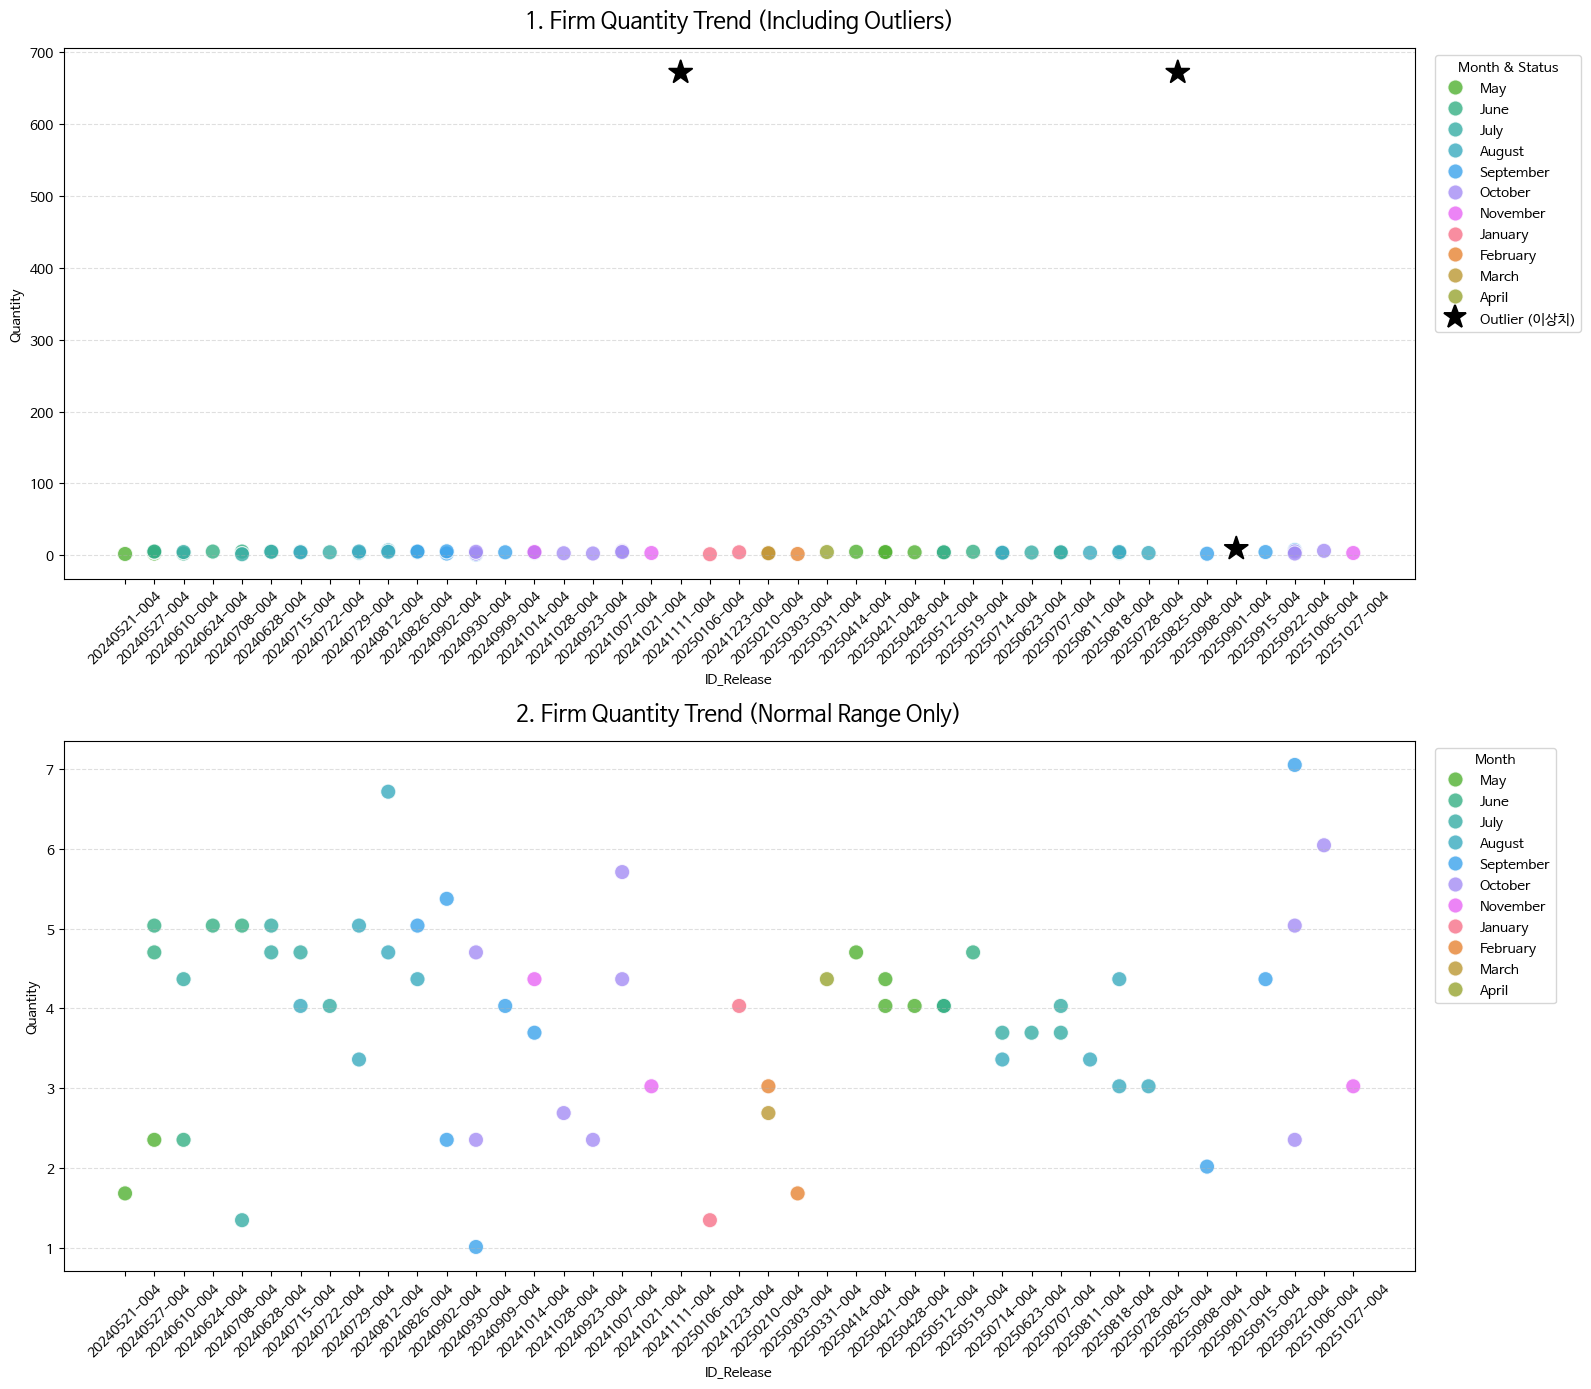

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 불러오기
file_name = '/content/A0067885_최신데이터.xlsx'
df = pd.read_excel(file_name)
df_firm = df[df['Firm/Forecast'].astype(str).str.strip().str.capitalize() == 'Firm'].copy()

# 날짜 정렬
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_firm['Month_Num'] = df_firm['Month'].str.strip().map(month_map)

# 연도, 월, 일, 그리고 ID_Release 순으로 강제 정렬
df_firm = df_firm.sort_values(by=['Year', 'Month_Num', 'Day', 'ID_Release'])

# 그래프에 표시될 ID_Release 순서를 고정하기 위해 카테고리형으로 변환
df_firm['ID_Release'] = pd.Categorical(df_firm['ID_Release'], categories=df_firm['ID_Release'].unique(), ordered=True)

# 이상치 판별 (IQR 방식)
Q1 = df_firm['Quantity'].quantile(0.25)
Q3 = df_firm['Quantity'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# Category 설정
df_firm['Category'] = df_firm.apply(
    lambda x: 'Outlier (이상치)' if (x['Quantity'] > upper_bound or x['Quantity'] < lower_bound)
    else x['Month'], axis=1
)

# 그래프 그리기
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))
plt.subplots_adjust(hspace=0.5)

# 색상 및 범례 순서 정렬을 위한 설정
unique_cats = [m for m in month_map.keys() if m in df_firm['Month'].unique()]
if 'Outlier (이상치)' in df_firm['Category'].values:
    unique_cats.append('Outlier (이상치)')

colors = sns.color_palette("husl", len(unique_cats))
color_map = {cat: colors[i] for i, cat in enumerate(unique_cats)}
if 'Outlier (이상치)' in color_map:
    color_map['Outlier (이상치)'] = '#000000' # 이상치는 검은색

# --- 이상치 포함 버전 ---
# 일반 데이터 (원형 'o')
df_1_normal = df_firm[df_firm['Category'] != 'Outlier (이상치)']
sns.scatterplot(data=df_1_normal, x='ID_Release', y='Quantity', hue='Category',
                palette=color_map, s=120, marker='o', ax=ax1, edgecolor='w', alpha=0.8)

# 이상치 데이터 (별표 '★')
df_1_out = df_firm[df_firm['Category'] == 'Outlier (이상치)']
sns.scatterplot(data=df_1_out, x='ID_Release', y='Quantity', hue='Category',
                palette=color_map, s=300, marker='*', ax=ax1, edgecolor='black', zorder=5)

ax1.set_title('1. Firm Quantity Trend (Including Outliers)', fontsize=16, pad=15)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Month & Status', bbox_to_anchor=(1.01, 1), loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --- 이상치 제외 버전 ---
df_normal_only = df_firm[df_firm['Category'] != 'Outlier (이상치)']
sns.scatterplot(data=df_normal_only, x='ID_Release', y='Quantity', hue='Category',
                palette=color_map, s=120, marker='o', ax=ax2, edgecolor='w', alpha=0.8)

ax2.set_title('2. Firm Quantity Trend (Normal Range Only)', fontsize=16, pad=15)
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Month', bbox_to_anchor=(1.01, 1), loc='upper left')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

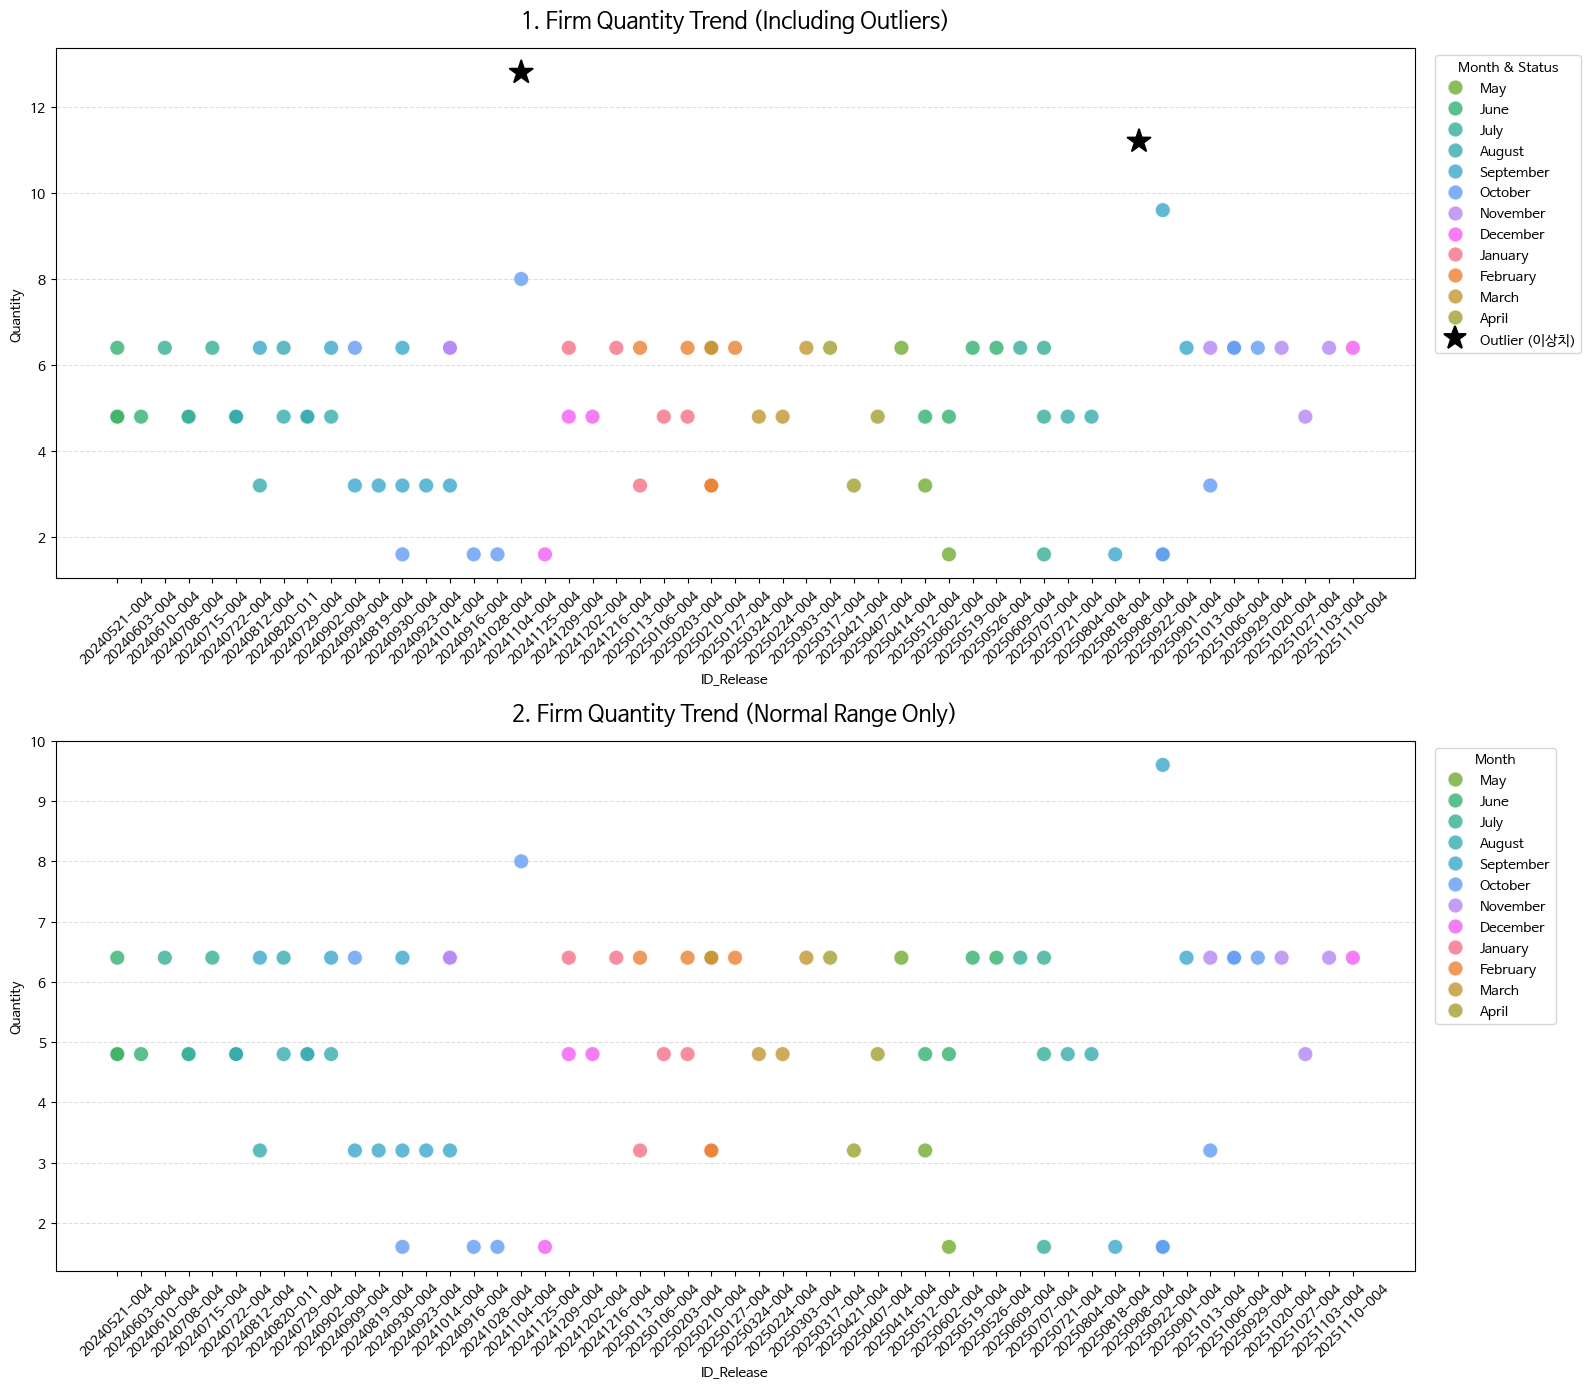

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 불러오기
file_name = '/content/A0028219_최신데이터.xlsx'
df = pd.read_excel(file_name)
df_firm = df[df['Firm/Forecast'].astype(str).str.strip().str.capitalize() == 'Firm'].copy()

# 날짜 정렬
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_firm['Month_Num'] = df_firm['Month'].str.strip().map(month_map)

# 연도, 월, 일, 그리고 ID_Release 순으로 강제 정렬
df_firm = df_firm.sort_values(by=['Year', 'Month_Num', 'Day', 'ID_Release'])

# 그래프에 표시될 ID_Release 순서를 고정하기 위해 카테고리형으로 변환
df_firm['ID_Release'] = pd.Categorical(df_firm['ID_Release'], categories=df_firm['ID_Release'].unique(), ordered=True)

# 이상치 판별 (IQR 방식)
Q1 = df_firm['Quantity'].quantile(0.25)
Q3 = df_firm['Quantity'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# Category 설정
df_firm['Category'] = df_firm.apply(
    lambda x: 'Outlier (이상치)' if (x['Quantity'] > upper_bound or x['Quantity'] < lower_bound)
    else x['Month'], axis=1
)

# 그래프 그리기
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))
plt.subplots_adjust(hspace=0.5)

# 색상 및 범례 순서 정렬을 위한 설정
unique_cats = [m for m in month_map.keys() if m in df_firm['Month'].unique()]
if 'Outlier (이상치)' in df_firm['Category'].values:
    unique_cats.append('Outlier (이상치)')

colors = sns.color_palette("husl", len(unique_cats))
color_map = {cat: colors[i] for i, cat in enumerate(unique_cats)}
if 'Outlier (이상치)' in color_map:
    color_map['Outlier (이상치)'] = '#000000' # 이상치는 검은색

# --- 이상치 포함 버전 ---
# 일반 데이터 (원형 'o')
df_1_normal = df_firm[df_firm['Category'] != 'Outlier (이상치)']
sns.scatterplot(data=df_1_normal, x='ID_Release', y='Quantity', hue='Category',
                palette=color_map, s=120, marker='o', ax=ax1, edgecolor='w', alpha=0.8)

# 이상치 데이터 (별표 '★')
df_1_out = df_firm[df_firm['Category'] == 'Outlier (이상치)']
sns.scatterplot(data=df_1_out, x='ID_Release', y='Quantity', hue='Category',
                palette=color_map, s=300, marker='*', ax=ax1, edgecolor='black', zorder=5)

ax1.set_title('1. Firm Quantity Trend (Including Outliers)', fontsize=16, pad=15)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Month & Status', bbox_to_anchor=(1.01, 1), loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --- 이상치 제외 버전 ---
df_normal_only = df_firm[df_firm['Category'] != 'Outlier (이상치)']
sns.scatterplot(data=df_normal_only, x='ID_Release', y='Quantity', hue='Category',
                palette=color_map, s=120, marker='o', ax=ax2, edgecolor='w', alpha=0.8)

ax2.set_title('2. Firm Quantity Trend (Normal Range Only)', fontsize=16, pad=15)
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Month', bbox_to_anchor=(1.01, 1), loc='upper left')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

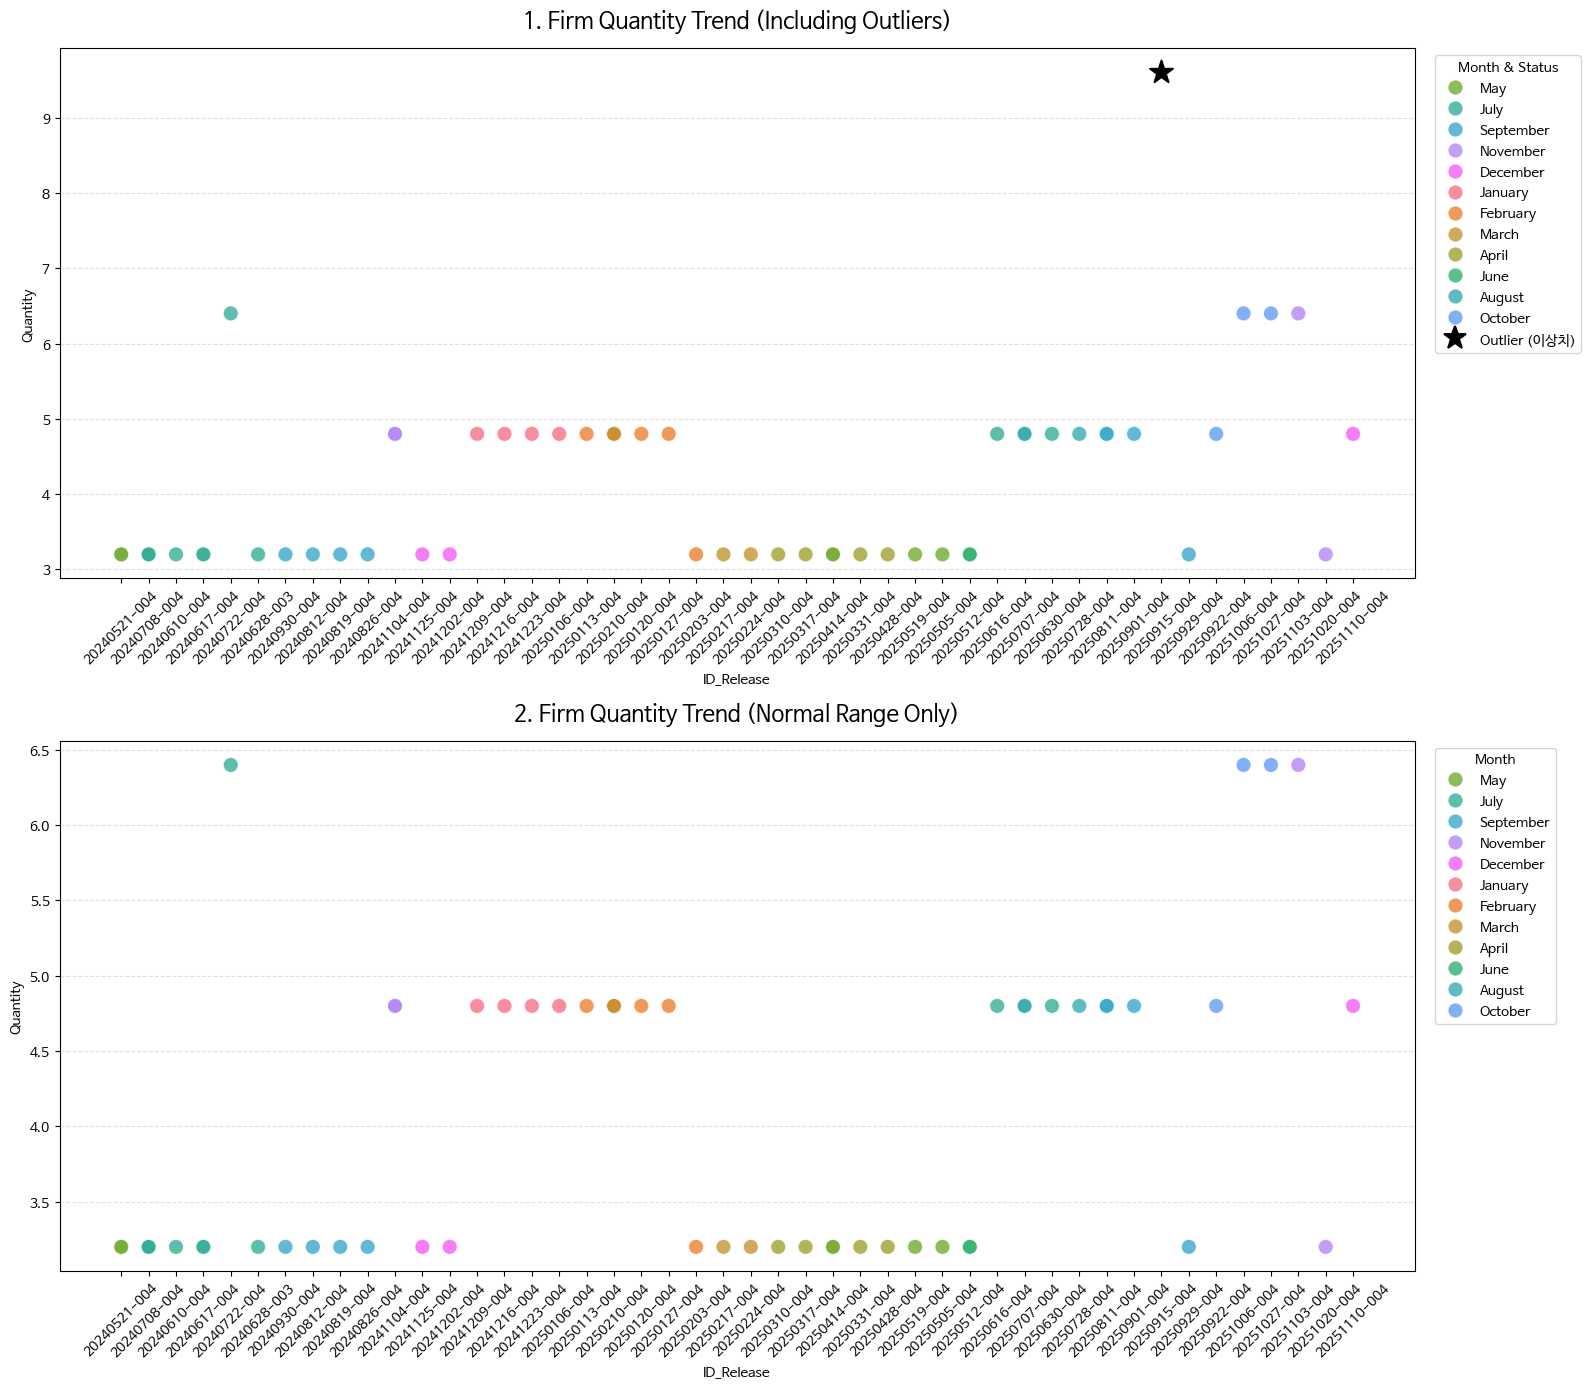

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 불러오기
file_name = '/content/A0030814X_최신데이터.xlsx'
df = pd.read_excel(file_name)
df_firm = df[df['Firm/Forecast'].astype(str).str.strip().str.capitalize() == 'Firm'].copy()

# 날짜 정렬
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_firm['Month_Num'] = df_firm['Month'].str.strip().map(month_map)

# 연도, 월, 일, 그리고 ID_Release 순으로 강제 정렬
df_firm = df_firm.sort_values(by=['Year', 'Month_Num', 'Day', 'ID_Release'])

# 그래프에 표시될 ID_Release 순서를 고정하기 위해 카테고리형으로 변환
df_firm['ID_Release'] = pd.Categorical(df_firm['ID_Release'], categories=df_firm['ID_Release'].unique(), ordered=True)

# 이상치 판별 (IQR 방식)
Q1 = df_firm['Quantity'].quantile(0.25)
Q3 = df_firm['Quantity'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# Category 설정
df_firm['Category'] = df_firm.apply(
    lambda x: 'Outlier (이상치)' if (x['Quantity'] > upper_bound or x['Quantity'] < lower_bound)
    else x['Month'], axis=1
)

# 그래프 그리기
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))
plt.subplots_adjust(hspace=0.5)

# 색상 및 범례 순서 정렬을 위한 설정
unique_cats = [m for m in month_map.keys() if m in df_firm['Month'].unique()]
if 'Outlier (이상치)' in df_firm['Category'].values:
    unique_cats.append('Outlier (이상치)')

colors = sns.color_palette("husl", len(unique_cats))
color_map = {cat: colors[i] for i, cat in enumerate(unique_cats)}
if 'Outlier (이상치)' in color_map:
    color_map['Outlier (이상치)'] = '#000000' # 이상치는 검은색

# --- 이상치 포함 버전 ---
# 일반 데이터 (원형 'o')
df_1_normal = df_firm[df_firm['Category'] != 'Outlier (이상치)']
sns.scatterplot(data=df_1_normal, x='ID_Release', y='Quantity', hue='Category',
                palette=color_map, s=120, marker='o', ax=ax1, edgecolor='w', alpha=0.8)

# 이상치 데이터 (별표 '★')
df_1_out = df_firm[df_firm['Category'] == 'Outlier (이상치)']
sns.scatterplot(data=df_1_out, x='ID_Release', y='Quantity', hue='Category',
                palette=color_map, s=300, marker='*', ax=ax1, edgecolor='black', zorder=5)

ax1.set_title('1. Firm Quantity Trend (Including Outliers)', fontsize=16, pad=15)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Month & Status', bbox_to_anchor=(1.01, 1), loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --- 이상치 제외 버전 ---
df_normal_only = df_firm[df_firm['Category'] != 'Outlier (이상치)']
sns.scatterplot(data=df_normal_only, x='ID_Release', y='Quantity', hue='Category',
                palette=color_map, s=120, marker='o', ax=ax2, edgecolor='w', alpha=0.8)

ax2.set_title('2. Firm Quantity Trend (Normal Range Only)', fontsize=16, pad=15)
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Month', bbox_to_anchor=(1.01, 1), loc='upper left')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

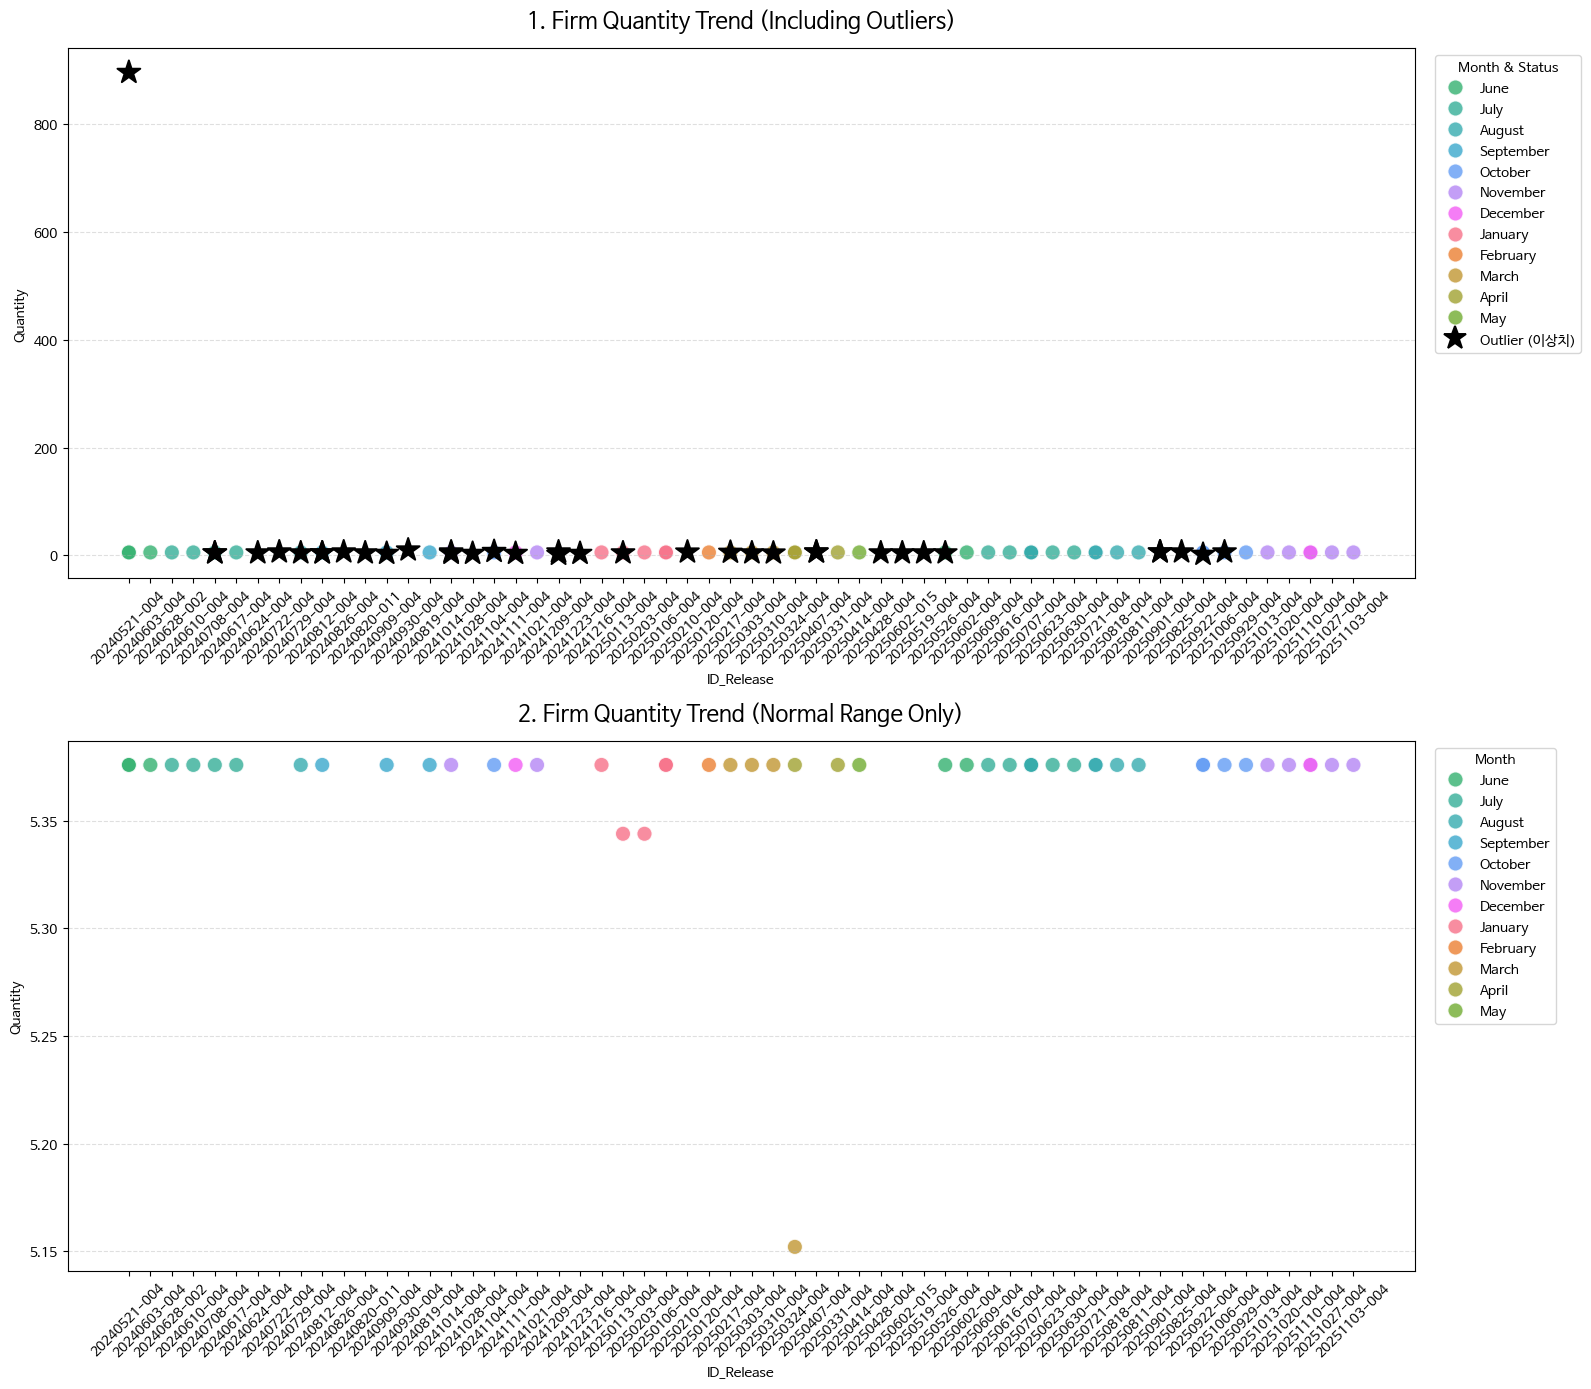

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 불러오기
file_name = '/content/A0049000_최신데이터.xlsx'
df = pd.read_excel(file_name)
df_firm = df[df['Firm/Forecast'].astype(str).str.strip().str.capitalize() == 'Firm'].copy()

# 날짜 정렬
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_firm['Month_Num'] = df_firm['Month'].str.strip().map(month_map)

# 연도, 월, 일, 그리고 ID_Release 순으로 강제 정렬
df_firm = df_firm.sort_values(by=['Year', 'Month_Num', 'Day', 'ID_Release'])

# 그래프에 표시될 ID_Release 순서를 고정하기 위해 카테고리형으로 변환
df_firm['ID_Release'] = pd.Categorical(df_firm['ID_Release'], categories=df_firm['ID_Release'].unique(), ordered=True)

# 이상치 판별 (IQR 방식)
Q1 = df_firm['Quantity'].quantile(0.25)
Q3 = df_firm['Quantity'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# Category 설정
df_firm['Category'] = df_firm.apply(
    lambda x: 'Outlier (이상치)' if (x['Quantity'] > upper_bound or x['Quantity'] < lower_bound)
    else x['Month'], axis=1
)

# 그래프 그리기
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))
plt.subplots_adjust(hspace=0.5)

# 색상 및 범례 순서 정렬을 위한 설정
unique_cats = [m for m in month_map.keys() if m in df_firm['Month'].unique()]
if 'Outlier (이상치)' in df_firm['Category'].values:
    unique_cats.append('Outlier (이상치)')

colors = sns.color_palette("husl", len(unique_cats))
color_map = {cat: colors[i] for i, cat in enumerate(unique_cats)}
if 'Outlier (이상치)' in color_map:
    color_map['Outlier (이상치)'] = '#000000' # 이상치는 검은색

# --- 이상치 포함 버전 ---
# 일반 데이터 (원형 'o')
df_1_normal = df_firm[df_firm['Category'] != 'Outlier (이상치)']
sns.scatterplot(data=df_1_normal, x='ID_Release', y='Quantity', hue='Category',
                palette=color_map, s=120, marker='o', ax=ax1, edgecolor='w', alpha=0.8)

# 이상치 데이터 (별표 '★')
df_1_out = df_firm[df_firm['Category'] == 'Outlier (이상치)']
sns.scatterplot(data=df_1_out, x='ID_Release', y='Quantity', hue='Category',
                palette=color_map, s=300, marker='*', ax=ax1, edgecolor='black', zorder=5)

ax1.set_title('1. Firm Quantity Trend (Including Outliers)', fontsize=16, pad=15)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Month & Status', bbox_to_anchor=(1.01, 1), loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --- 이상치 제외 버전 ---
df_normal_only = df_firm[df_firm['Category'] != 'Outlier (이상치)']
sns.scatterplot(data=df_normal_only, x='ID_Release', y='Quantity', hue='Category',
                palette=color_map, s=120, marker='o', ax=ax2, edgecolor='w', alpha=0.8)

ax2.set_title('2. Firm Quantity Trend (Normal Range Only)', fontsize=16, pad=15)
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Month', bbox_to_anchor=(1.01, 1), loc='upper left')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

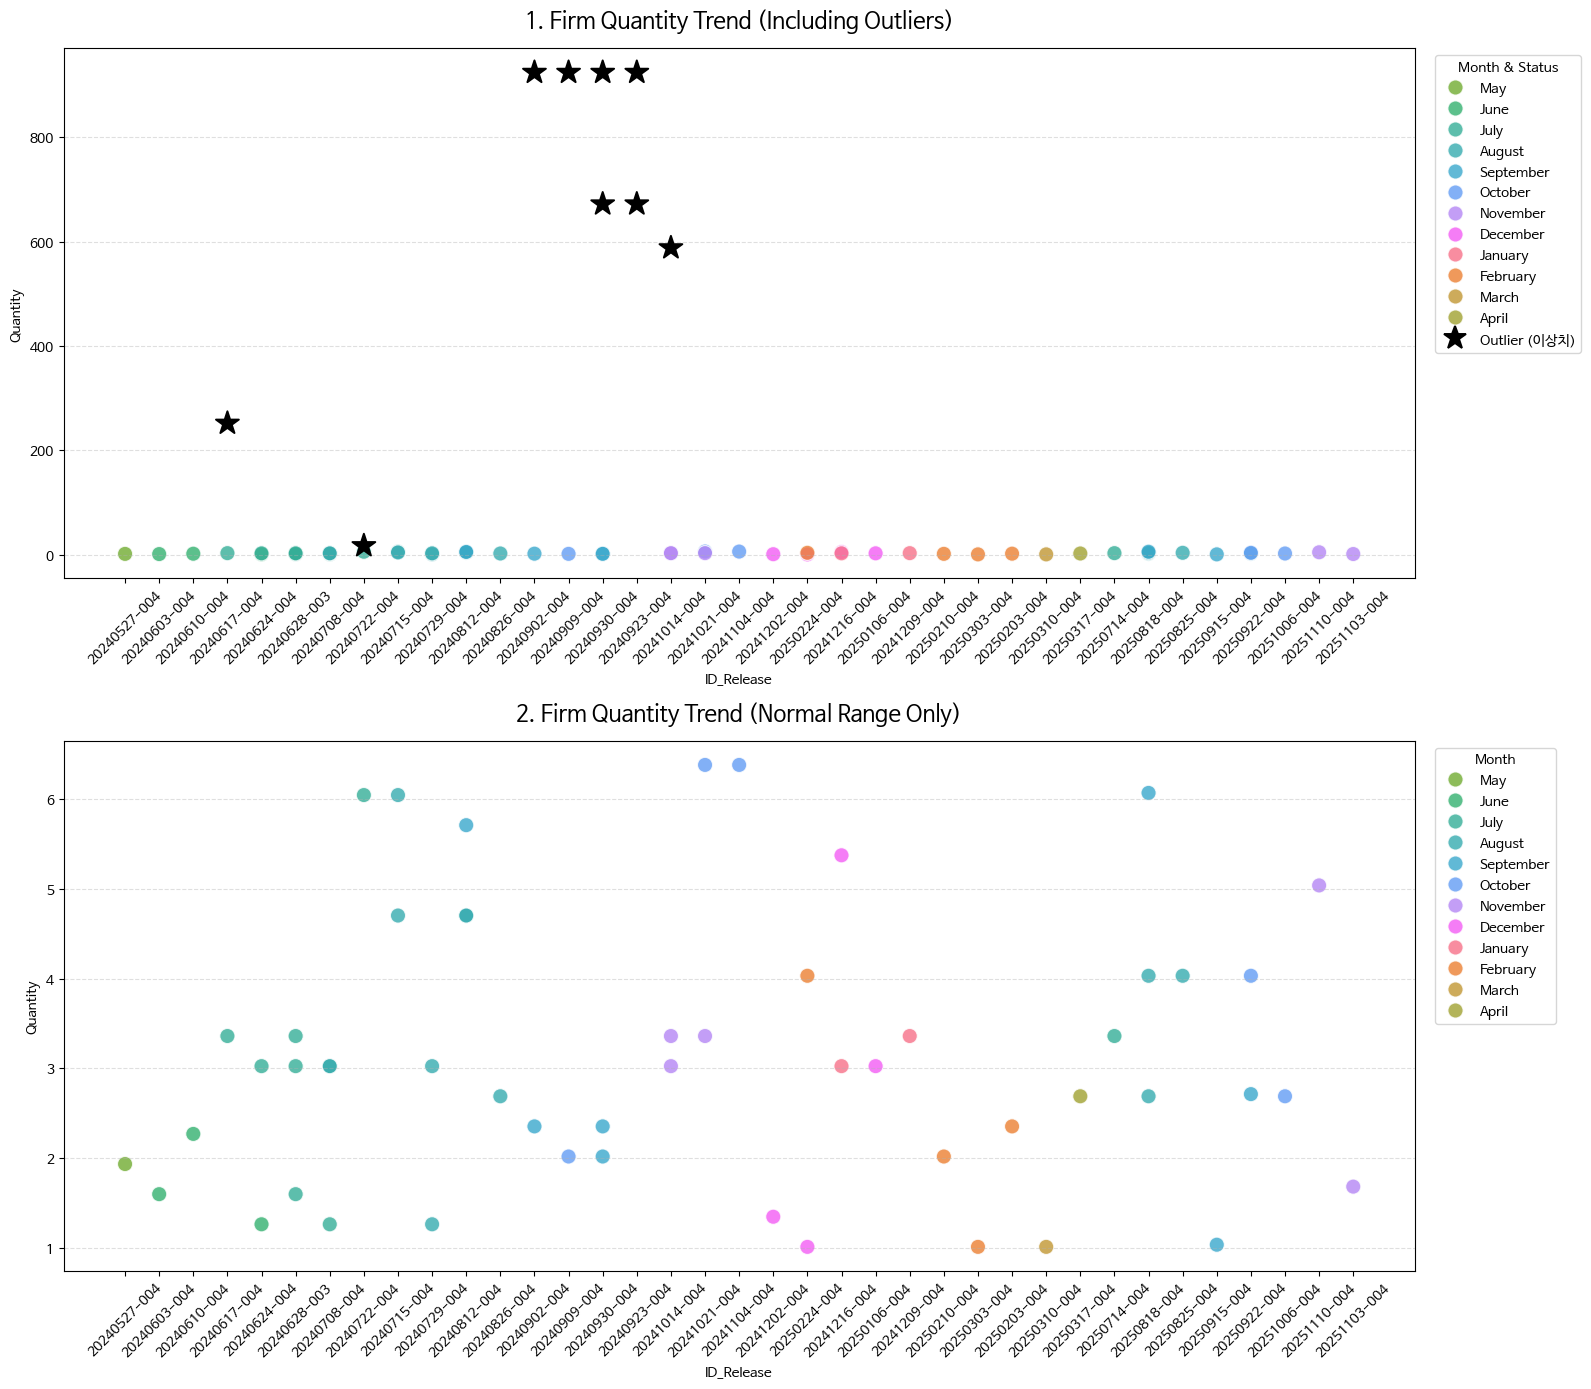

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 불러오기
file_name = '/content/A0070270_최신데이터.xlsx'
df = pd.read_excel(file_name)
df_firm = df[df['Firm/Forecast'].astype(str).str.strip().str.capitalize() == 'Firm'].copy()

# 날짜 정렬
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_firm['Month_Num'] = df_firm['Month'].str.strip().map(month_map)

# 연도, 월, 일, 그리고 ID_Release 순으로 강제 정렬
df_firm = df_firm.sort_values(by=['Year', 'Month_Num', 'Day', 'ID_Release'])

# 그래프에 표시될 ID_Release 순서를 고정하기 위해 카테고리형으로 변환
df_firm['ID_Release'] = pd.Categorical(df_firm['ID_Release'], categories=df_firm['ID_Release'].unique(), ordered=True)

# 이상치 판별 (IQR 방식)
Q1 = df_firm['Quantity'].quantile(0.25)
Q3 = df_firm['Quantity'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# Category 설정
df_firm['Category'] = df_firm.apply(
    lambda x: 'Outlier (이상치)' if (x['Quantity'] > upper_bound or x['Quantity'] < lower_bound)
    else x['Month'], axis=1
)

# 그래프 그리기
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))
plt.subplots_adjust(hspace=0.5)

# 색상 및 범례 순서 정렬을 위한 설정
unique_cats = [m for m in month_map.keys() if m in df_firm['Month'].unique()]
if 'Outlier (이상치)' in df_firm['Category'].values:
    unique_cats.append('Outlier (이상치)')

colors = sns.color_palette("husl", len(unique_cats))
color_map = {cat: colors[i] for i, cat in enumerate(unique_cats)}
if 'Outlier (이상치)' in color_map:
    color_map['Outlier (이상치)'] = '#000000' # 이상치는 검은색

# --- 이상치 포함 버전 ---
# 일반 데이터 (원형 'o')
df_1_normal = df_firm[df_firm['Category'] != 'Outlier (이상치)']
sns.scatterplot(data=df_1_normal, x='ID_Release', y='Quantity', hue='Category',
                palette=color_map, s=120, marker='o', ax=ax1, edgecolor='w', alpha=0.8)

# 이상치 데이터 (별표 '★')
df_1_out = df_firm[df_firm['Category'] == 'Outlier (이상치)']
sns.scatterplot(data=df_1_out, x='ID_Release', y='Quantity', hue='Category',
                palette=color_map, s=300, marker='*', ax=ax1, edgecolor='black', zorder=5)

ax1.set_title('1. Firm Quantity Trend (Including Outliers)', fontsize=16, pad=15)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Month & Status', bbox_to_anchor=(1.01, 1), loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --- 이상치 제외 버전 ---
df_normal_only = df_firm[df_firm['Category'] != 'Outlier (이상치)']
sns.scatterplot(data=df_normal_only, x='ID_Release', y='Quantity', hue='Category',
                palette=color_map, s=120, marker='o', ax=ax2, edgecolor='w', alpha=0.8)

ax2.set_title('2. Firm Quantity Trend (Normal Range Only)', fontsize=16, pad=15)
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Month', bbox_to_anchor=(1.01, 1), loc='upper left')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

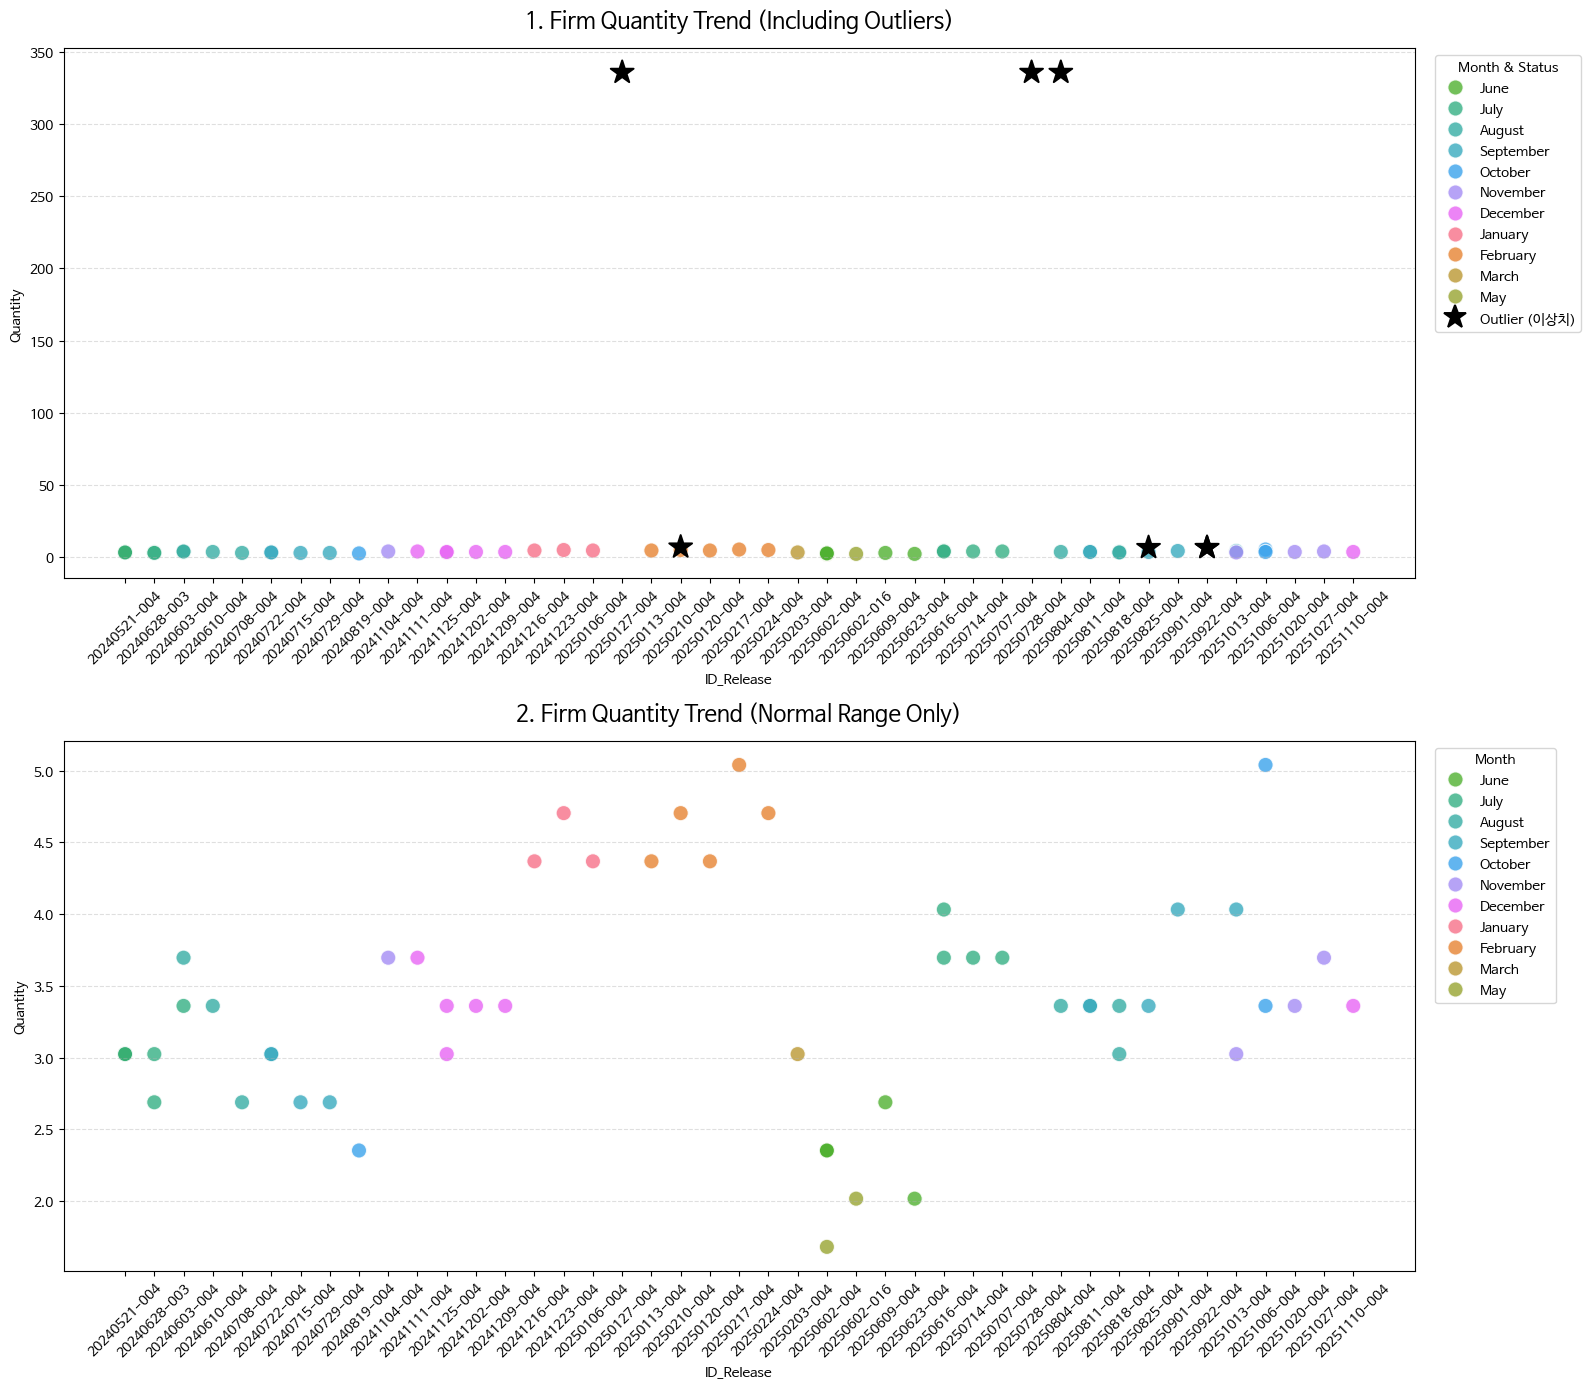

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 불러오기
file_name = '/content/A021N565_최신데이터.xlsx'
df = pd.read_excel(file_name)
df_firm = df[df['Firm/Forecast'].astype(str).str.strip().str.capitalize() == 'Firm'].copy()

# 날짜 정렬
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_firm['Month_Num'] = df_firm['Month'].str.strip().map(month_map)

# 연도, 월, 일, 그리고 ID_Release 순으로 강제 정렬
df_firm = df_firm.sort_values(by=['Year', 'Month_Num', 'Day', 'ID_Release'])

# 그래프에 표시될 ID_Release 순서를 고정하기 위해 카테고리형으로 변환
df_firm['ID_Release'] = pd.Categorical(df_firm['ID_Release'], categories=df_firm['ID_Release'].unique(), ordered=True)

# 이상치 판별 (IQR 방식)
Q1 = df_firm['Quantity'].quantile(0.25)
Q3 = df_firm['Quantity'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# Category 설정
df_firm['Category'] = df_firm.apply(
    lambda x: 'Outlier (이상치)' if (x['Quantity'] > upper_bound or x['Quantity'] < lower_bound)
    else x['Month'], axis=1
)

# 그래프 그리기
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))
plt.subplots_adjust(hspace=0.5)

# 색상 및 범례 순서 정렬을 위한 설정
unique_cats = [m for m in month_map.keys() if m in df_firm['Month'].unique()]
if 'Outlier (이상치)' in df_firm['Category'].values:
    unique_cats.append('Outlier (이상치)')

colors = sns.color_palette("husl", len(unique_cats))
color_map = {cat: colors[i] for i, cat in enumerate(unique_cats)}
if 'Outlier (이상치)' in color_map:
    color_map['Outlier (이상치)'] = '#000000' # 이상치는 검은색

# --- 이상치 포함 버전 ---
# 일반 데이터 (원형 'o')
df_1_normal = df_firm[df_firm['Category'] != 'Outlier (이상치)']
sns.scatterplot(data=df_1_normal, x='ID_Release', y='Quantity', hue='Category',
                palette=color_map, s=120, marker='o', ax=ax1, edgecolor='w', alpha=0.8)

# 이상치 데이터 (별표 '★')
df_1_out = df_firm[df_firm['Category'] == 'Outlier (이상치)']
sns.scatterplot(data=df_1_out, x='ID_Release', y='Quantity', hue='Category',
                palette=color_map, s=300, marker='*', ax=ax1, edgecolor='black', zorder=5)

ax1.set_title('1. Firm Quantity Trend (Including Outliers)', fontsize=16, pad=15)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Month & Status', bbox_to_anchor=(1.01, 1), loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --- 이상치 제외 버전 ---
df_normal_only = df_firm[df_firm['Category'] != 'Outlier (이상치)']
sns.scatterplot(data=df_normal_only, x='ID_Release', y='Quantity', hue='Category',
                palette=color_map, s=120, marker='o', ax=ax2, edgecolor='w', alpha=0.8)

ax2.set_title('2. Firm Quantity Trend (Normal Range Only)', fontsize=16, pad=15)
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Month', bbox_to_anchor=(1.01, 1), loc='upper left')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**결과 해석**

In [ ]:
# A0067885


# A0028219


# A0030814X


# A0049000


# A0070270


# A021N565

